In [17]:
from google.colab import files
uploaded = files.upload()

Saving matches.csv to matches (1).csv


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("/content/matches.csv")

In [19]:
df.head(5)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [21]:
df.shape

(1095, 20)

In [22]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [23]:
df.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [24]:
#
print(df[df['city'].isnull()][['city','venue']].head(10))

    city                                venue
399  NaN              Sharjah Cricket Stadium
402  NaN  Dubai International Cricket Stadium
403  NaN  Dubai International Cricket Stadium
404  NaN              Sharjah Cricket Stadium
406  NaN              Sharjah Cricket Stadium
407  NaN  Dubai International Cricket Stadium
408  NaN              Sharjah Cricket Stadium
409  NaN  Dubai International Cricket Stadium
410  NaN  Dubai International Cricket Stadium
413  NaN              Sharjah Cricket Stadium


In [25]:
df['city'] = df['city'].fillna('Unknown')

In [26]:
df["player_of_match"]=df["player_of_match"].fillna('Unknown')

In [27]:
df = df.dropna(subset=['winner'])


In [28]:
df.shape

(1090, 20)

In [29]:
print(df['result_margin'].isnull().sum())  # since 5 rows have reduced so recalculation
df['result_margin'] = df['result_margin'].fillna(0)

14


In [30]:
df["target_runs"]=df["target_runs"].fillna(0)

In [31]:
df["target_overs"]=df["target_overs"].fillna(0)

In [32]:
#method will null values signify that the matches were normal
df['method'] = df['method'].fillna('Normal')


In [33]:
print(df.isnull().sum())

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64


In [34]:
print(f"Dataset now has {df.shape[0]} matches ready for analysis")

Dataset now has 1090 matches ready for analysis


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


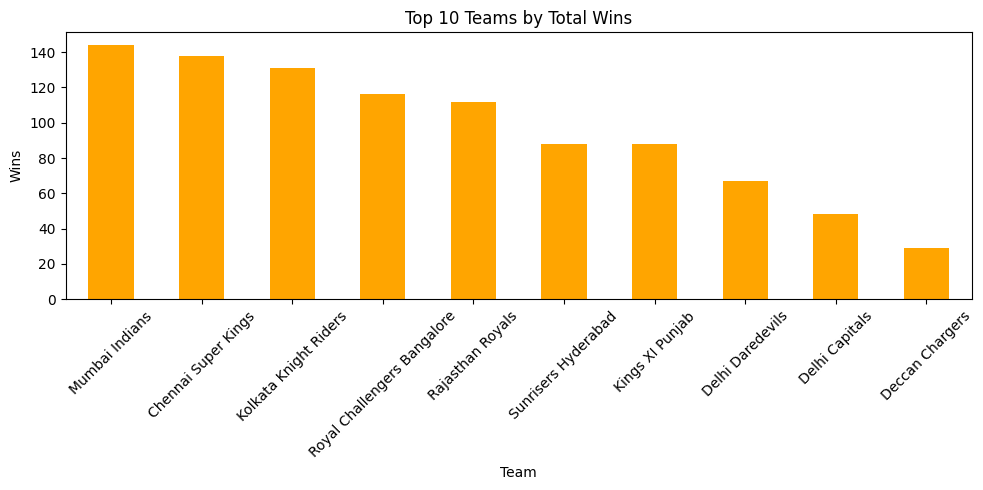

In [35]:
wins = df['winner'].value_counts()
print(wins.head(10))

wins.head(10).plot(kind='bar', color='orange', figsize=(10,5))
plt.title('Top 10 Teams by Total Wins')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

toss_decision
field    700
bat      390
Name: count, dtype: int64


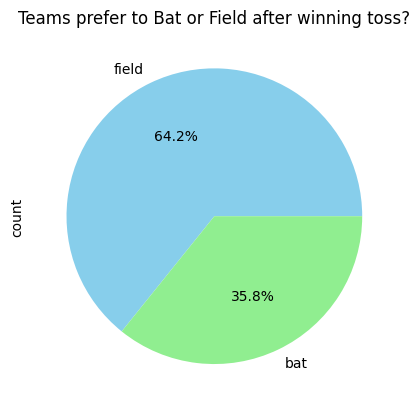

In [36]:
toss = df['toss_decision'].value_counts()
print(toss)

toss.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','lightgreen'])
plt.title('Teams prefer to Bat or Field after winning toss?')
plt.show()

toss_win_match_win
True     554
False    536
Name: count, dtype: int64


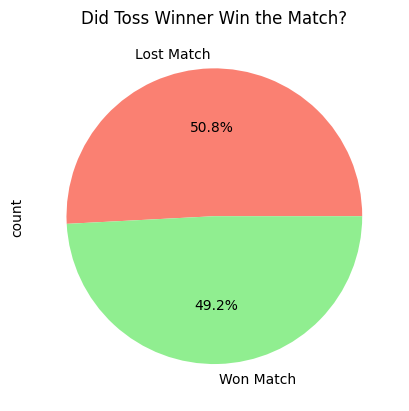

In [37]:
df['toss_win_match_win'] = df['toss_winner'] == df['winner']

result = df['toss_win_match_win'].value_counts()
print(result)

result.plot(kind='pie', labels=['Lost Match','Won Match'],
            autopct='%1.1f%%', colors=['salmon','lightgreen'])
plt.title('Did Toss Winner Win the Match?')
plt.show()

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


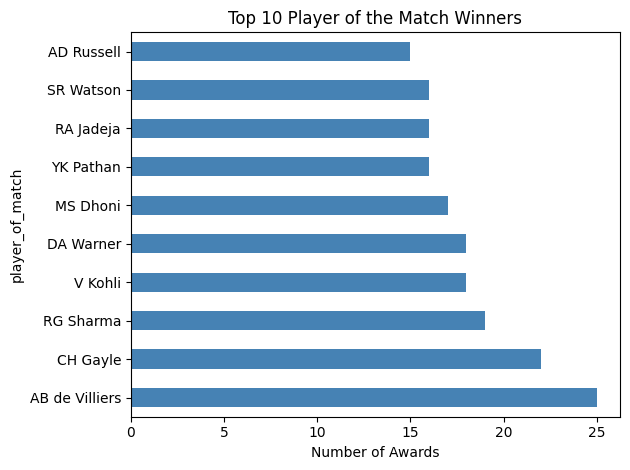

In [38]:
# Most player of match awards
pom = df['player_of_match'].value_counts().head(10)
print(pom)

pom.plot(kind='barh', color='steelblue')
plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Number of Awards')
plt.tight_layout()
plt.show()

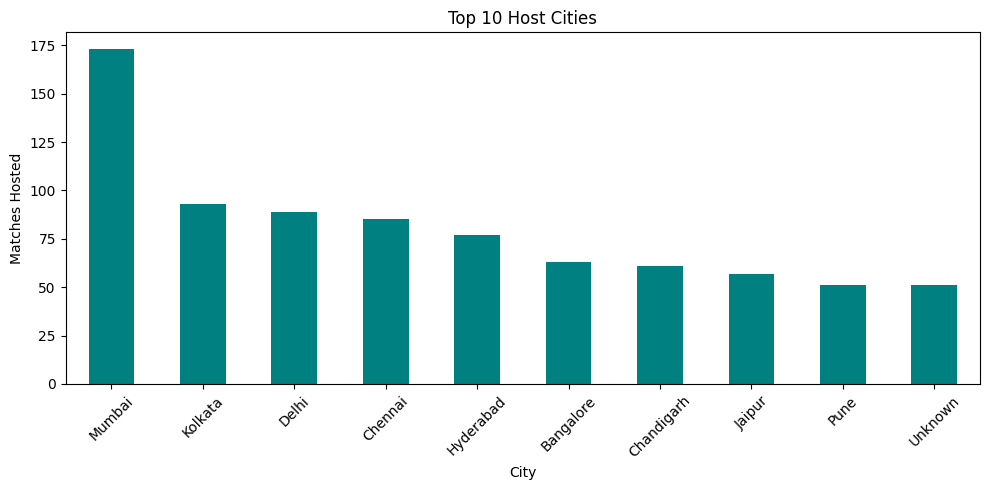

In [39]:
#cities that hosted most matches
cities = df['city'].value_counts().head(10)

cities.plot(kind='bar', color='teal', figsize=(10,5))
plt.title('Top 10 Host Cities')
plt.xlabel('City')
plt.ylabel('Matches Hosted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

result
wickets    578
runs       498
tie         14
Name: count, dtype: int64


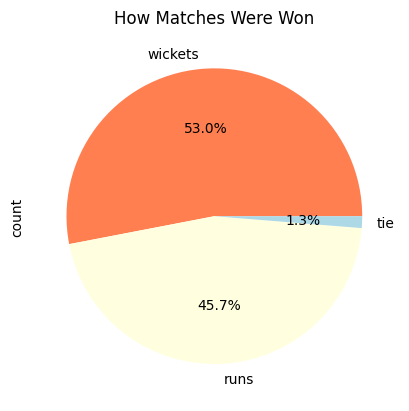

In [40]:
#win by runs vs win by wickets and tie
result_type = df['result'].value_counts()
print(result_type)

result_type.plot(kind='pie', autopct='%1.1f%%',
                 colors=['coral','lightyellow','lightblue'])
plt.title('How Matches Were Won')
plt.show()

In [41]:
#biggest wins by run margin
big_wins = df[df['result'] == 'runs'].sort_values(
    'result_margin', ascending=False).head(5)

print(big_wins[['season','team1','team2','winner','result_margin']])

      season                        team1                  team2  \
620     2017             Delhi Daredevils         Mumbai Indians   
560     2016  Royal Challengers Bangalore          Gujarat Lions   
0    2007/08  Royal Challengers Bangalore  Kolkata Knight Riders   
496     2015  Royal Challengers Bangalore        Kings XI Punjab   
352     2013  Royal Challengers Bangalore          Pune Warriors   

                          winner  result_margin  
620               Mumbai Indians          146.0  
560  Royal Challengers Bangalore          144.0  
0          Kolkata Knight Riders          140.0  
496  Royal Challengers Bangalore          138.0  
352  Royal Challengers Bangalore          130.0  
